Found 13 EW files to process.
  IC3392: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (438, 437)
  NGC4064: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (665, 566)
  NGC4192: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (1629, 1092)
  NGC4293: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (532, 923)
  NGC4298: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (995, 1042)
  NGC4330: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (760, 881)
  NGC4383: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (705, 633)
  NGC4396: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (755, 883)
  NGC4419: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (643, 628)
  NGC4457: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (725, 725)
  NGC4501: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (1236, 1205)
  NGC4522: loaded LOGSFR_SURFACE_DENSITY_HII and HA6562_EW with shape (659,

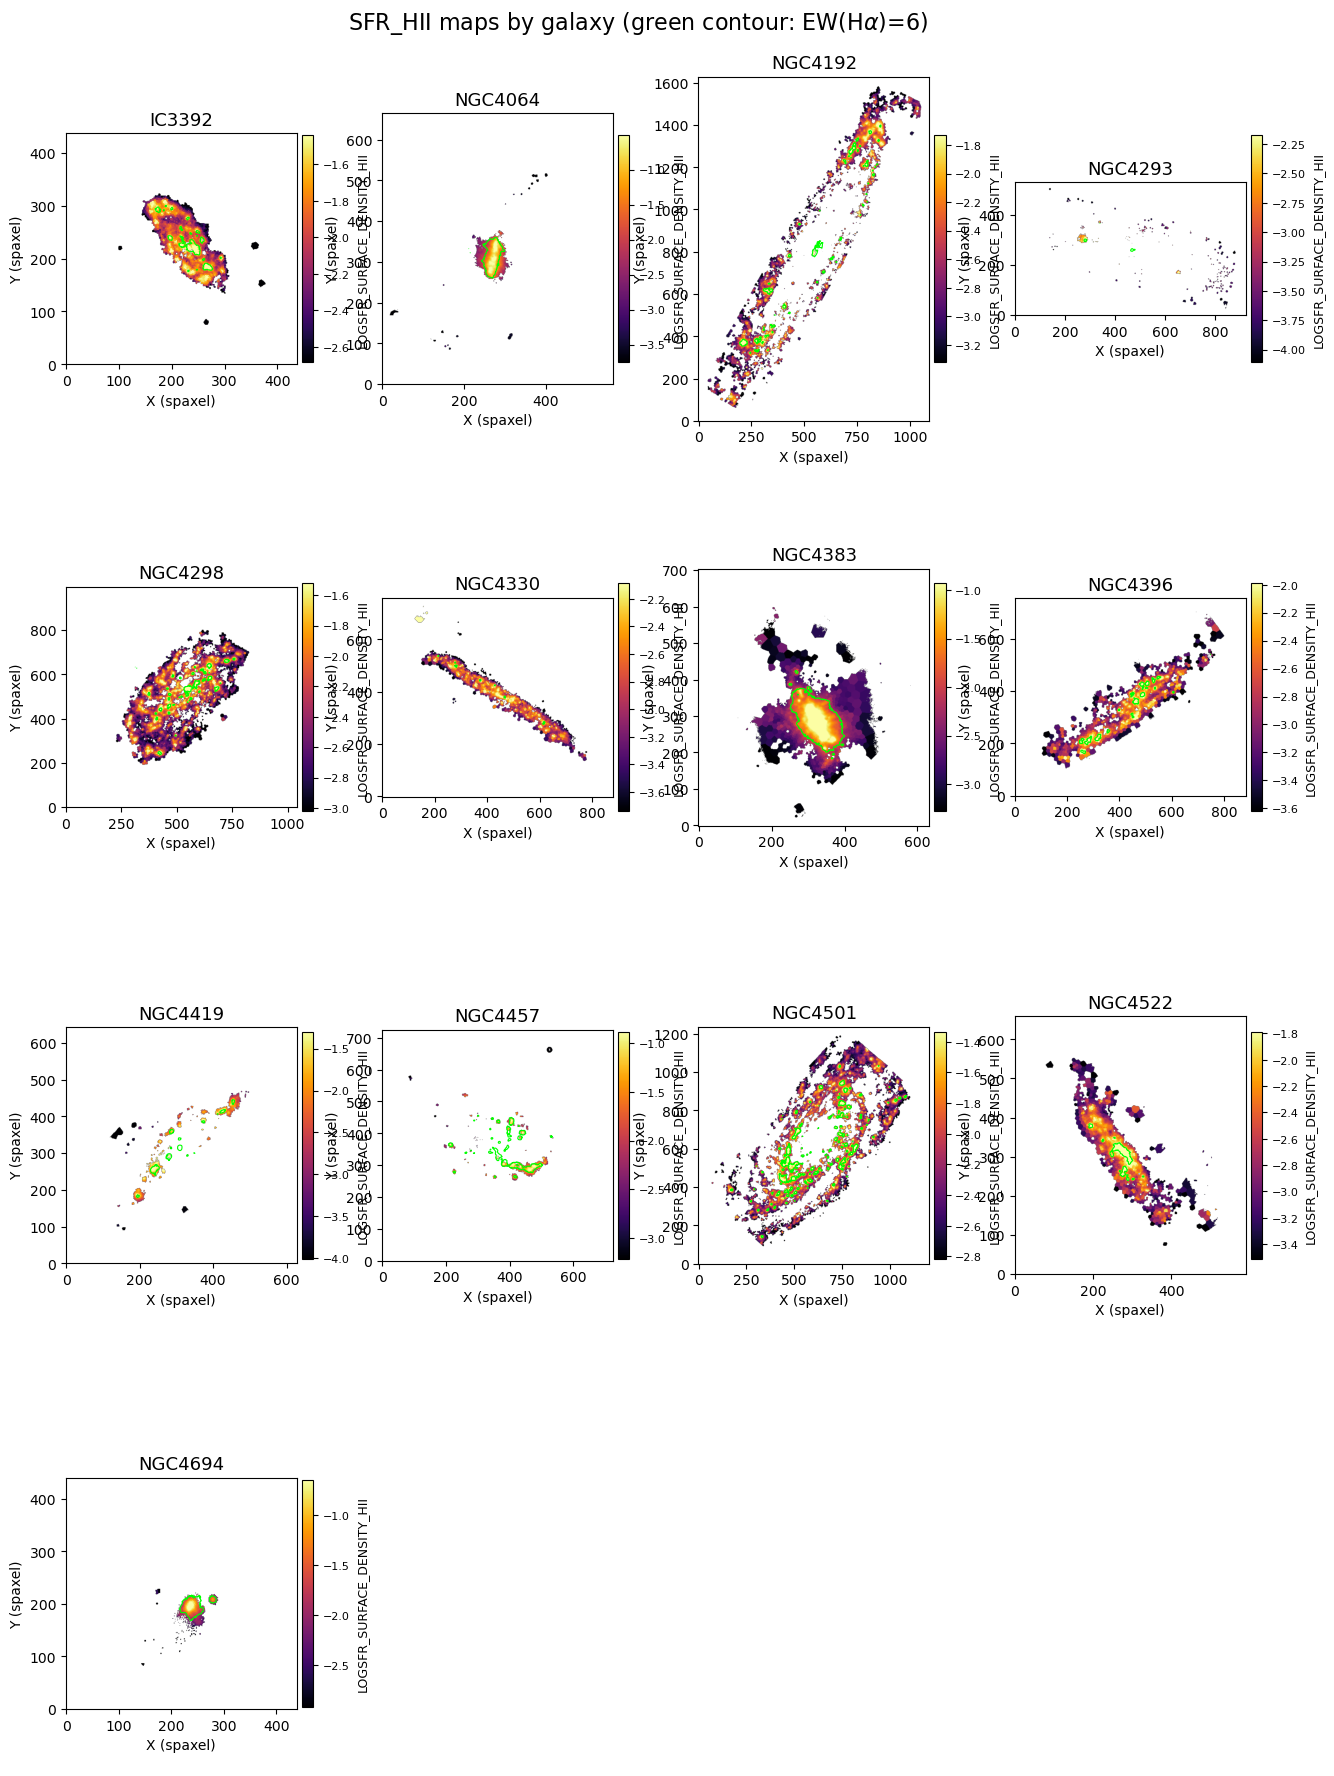


Plotted SFR_HII maps for 13 galaxies.


In [1]:
# ------------------------------------------------------------------
# SFR_HII maps for all galaxies in the current directory
# Read SFR_HII from XXX_gas_BIN_maps_extended.fits
# Overlay EW(H$\alpha$)=6 contour from XXX_v0.7dev_gas_BIN_maps.fits
# Plot one galaxy per subplot with 4 columns
# ------------------------------------------------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits

EW_STRICT_MIN = 6.0
SFR_HDU_CANDIDATES = ("LOGSFR_SURFACE_DENSITY_HII", "SFR_HII")

ew_files = sorted(Path(".").glob("*_v0.7dev_gas_BIN_maps.fits"))
if len(ew_files) == 0:
    raise FileNotFoundError("No *_v0.7dev_gas_BIN_maps.fits files found in the current directory.")

galaxy_maps = []
missing_ew = []
missing_sfr = []
missing_gas_file = []

print(f"Found {len(ew_files)} EW files to process.")
for ew_file in ew_files:
    galaxy = ew_file.name.replace("_v0.7dev_gas_BIN_maps.fits", "")
    gas_file = Path(f"{galaxy}_gas_BIN_maps_extended.fits")

    if not gas_file.exists():
        missing_gas_file.append(galaxy)
        print(f"  {galaxy}: missing file {gas_file.name}")
        continue

    try:
        with fits.open(ew_file) as h_ew:
            if "HA6562_EW" not in h_ew:
                missing_ew.append(galaxy)
                print(f"  {galaxy}: missing HDU HA6562_EW")
                continue
            ew_map = np.array(h_ew["HA6562_EW"].data, dtype=float)

        with fits.open(gas_file) as h_gas:
            sfr_hdu = next((name for name in SFR_HDU_CANDIDATES if name in h_gas), None)
            if sfr_hdu is None:
                missing_sfr.append(galaxy)
                print(f"  {galaxy}: missing SFR HDU (tried {', '.join(SFR_HDU_CANDIDATES)})")
                continue
            sfr_map = np.array(h_gas[sfr_hdu].data, dtype=float)

        if ew_map.ndim != 2:
            print(f"  {galaxy}: HA6562_EW is not 2D (shape={ew_map.shape}), skipping")
            continue
        if sfr_map.ndim != 2:
            print(f"  {galaxy}: {sfr_hdu} is not 2D (shape={sfr_map.shape}), skipping")
            continue
        if ew_map.shape != sfr_map.shape:
            print(f"  {galaxy}: shape mismatch EW {ew_map.shape} vs SFR {sfr_map.shape}, skipping")
            continue

        ew_map[~np.isfinite(ew_map)] = np.nan
        sfr_map[~np.isfinite(sfr_map)] = np.nan
        galaxy_maps.append((galaxy, sfr_map, ew_map, sfr_hdu))
        print(f"  {galaxy}: loaded {sfr_hdu} and HA6562_EW with shape {sfr_map.shape}")
    except Exception as e:
        print(f"  {galaxy}: failed to read files ({e})")

if len(galaxy_maps) == 0:
    raise RuntimeError("No valid SFR_HII + HA6562_EW map pairs were loaded.")

n_galaxies = len(galaxy_maps)
ncols = 4
nrows = math.ceil(n_galaxies / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(13, 4.8 * nrows),
    squeeze=False,
)
plt.subplots_adjust(left=0.06, right=0.98, bottom=0.06, top=0.94, wspace=0.28, hspace=0.30)

for i, (galaxy, sfr_map, ew_map, sfr_hdu) in enumerate(galaxy_maps):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    finite_sfr = sfr_map[np.isfinite(sfr_map)]
    if finite_sfr.size == 0:
        ax.set_title(f"{galaxy} (no finite SFR values)", fontsize=13)
        ax.axis("off")
        continue

    vmin_local, vmax_local = np.nanpercentile(finite_sfr, [5, 95])
    if (not np.isfinite(vmin_local)) or (not np.isfinite(vmax_local)) or (vmin_local == vmax_local):
        vmin_local = np.nanmin(finite_sfr)
        vmax_local = np.nanmax(finite_sfr)

    im = ax.imshow(
        sfr_map,
        origin="lower",
        cmap="inferno",
        vmin=vmin_local,
        vmax=vmax_local,
    )

    finite_ew = ew_map[np.isfinite(ew_map)]
    if finite_ew.size > 0 and np.nanmin(finite_ew) <= EW_STRICT_MIN <= np.nanmax(finite_ew):
        ax.contour(
            ew_map,
            levels=[EW_STRICT_MIN],
            colors="lime",
            linewidths=0.8,
            origin="lower",
        )

    ax.set_title(galaxy, fontsize=13)
    ax.set_xlabel("X (spaxel)")
    ax.set_ylabel("Y (spaxel)")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label(sfr_hdu, fontsize=9)
    cbar.ax.tick_params(labelsize=8)

for j in range(n_galaxies, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis("off")

fig.suptitle("SFR_HII maps by galaxy (green contour: EW(H$\\alpha$)=6)", fontsize=16, y=0.975)
plt.show()

print(f"\nPlotted SFR_HII maps for {n_galaxies} galaxies.")
if missing_gas_file:
    print("Galaxies skipped (missing *_gas_BIN_maps_extended.fits): " + ", ".join(missing_gas_file))
if missing_sfr:
    print("Galaxies skipped (missing SFR HDU): " + ", ".join(missing_sfr))
if missing_ew:
    print("Galaxies skipped (missing HA6562_EW): " + ", ".join(missing_ew))

sSFR vs EW(Halpha) analysis
Using all finite spaxels with EW > 0 (required by log-x); no EW>=6 cut.
Found 14 galaxies.

Processing IC3392 ...
  usable spaxels (finite + EW>0): 14906

Processing NGC4064 ...
  usable spaxels (finite + EW>0): 7077

Processing NGC4192 ...
  usable spaxels (finite + EW>0): 146165

Processing NGC4293 ...
  usable spaxels (finite + EW>0): 5607

Processing NGC4298 ...
  usable spaxels (finite + EW>0): 156571

Processing NGC4330 ...
  usable spaxels (finite + EW>0): 42956

Processing NGC4383 ...
  usable spaxels (finite + EW>0): 75134

Processing NGC4396 ...
  usable spaxels (finite + EW>0): 81745

Processing NGC4419 ...
  usable spaxels (finite + EW>0): 7386

Processing NGC4457 ...
  usable spaxels (finite + EW>0): 6354

Processing NGC4501 ...
  usable spaxels (finite + EW>0): 261541

Processing NGC4522 ...
  usable spaxels (finite + EW>0): 39619

Processing NGC4694 ...
  usable spaxels (finite + EW>0): 2586

Processing NGC4698 ...
  skipped: Missing file: NGC

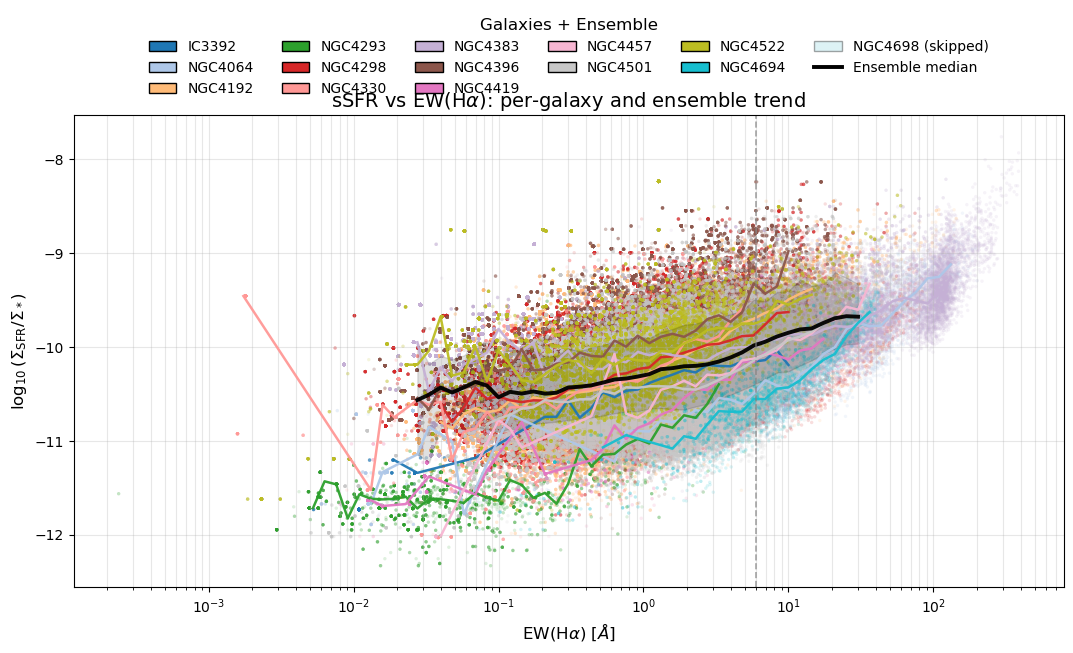


Plotted 13 galaxies.
Total usable spaxels used: 847647
Reference line only at EW=6.0; no EW threshold cut applied.
Skipped galaxies (color reserved in colormap):
  - NGC4698: Missing file: NGC4698_v0.7dev_gas_BIN_maps.fits


In [2]:
# ------------------------------------------------------------------
# sSFR vs EW(H$\alpha$): per-galaxy relations + ensemble trend
# sSFR is computed as log10(Sigma_SFR / Sigma_*) = logSigmaSFR - logSigmaM
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

EW_REF_LINE = 6.0       # visual reference only (no EW cut applied to data)
LOGEW_BIN_WIDTH = 0.08  # dex in log10(EW)
MIN_BIN_COUNT = 30      # minimum points per EW bin for median trend


def load_maps_for_ssfr_ew(gal):
    """Load logSigmaM, logSigmaSFR(HII), and EW(Halpha) maps for one galaxy."""
    spatial_path = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_path = Path(f"{gal}_gas_BIN_maps_extended.fits")
    ew_path = Path(f"{gal}_v0.7dev_gas_BIN_maps.fits")

    if not spatial_path.exists():
        raise FileNotFoundError(f"Missing file: {spatial_path.name}")
    if not gas_path.exists():
        raise FileNotFoundError(f"Missing file: {gas_path.name}")
    if not ew_path.exists():
        raise FileNotFoundError(f"Missing file: {ew_path.name}")

    with fits.open(spatial_path) as h_spatial:
        if "LOGMASS_SURFACE_DENSITY" not in h_spatial:
            raise KeyError("Missing HDU LOGMASS_SURFACE_DENSITY")
        log_sigma_m = np.array(h_spatial["LOGMASS_SURFACE_DENSITY"].data, dtype=float)

    with fits.open(gas_path) as h_gas:
        if "LOGSFR_SURFACE_DENSITY_HII" in h_gas:
            log_sigma_sfr = np.array(h_gas["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float)
        elif "SFR_HII" in h_gas:
            sfr_linear = np.array(h_gas["SFR_HII"].data, dtype=float)
            log_sigma_sfr = np.full_like(sfr_linear, np.nan, dtype=float)
            positive = np.isfinite(sfr_linear) & (sfr_linear > 0)
            log_sigma_sfr[positive] = np.log10(sfr_linear[positive])
        else:
            raise KeyError("Missing HDU LOGSFR_SURFACE_DENSITY_HII (or fallback SFR_HII)")

    with fits.open(ew_path) as h_ew:
        if "HA6562_EW" not in h_ew:
            raise KeyError("Missing HDU HA6562_EW")
        ew_ha = np.array(h_ew["HA6562_EW"].data, dtype=float)

    if log_sigma_m.shape != log_sigma_sfr.shape or log_sigma_m.shape != ew_ha.shape:
        raise ValueError(
            "Shape mismatch: "
            f"logSigmaM={log_sigma_m.shape}, logSigmaSFR={log_sigma_sfr.shape}, EW={ew_ha.shape}"
        )

    return log_sigma_m, log_sigma_sfr, ew_ha


def binned_median_logx(x, y, log_bin_width=0.08, min_count=30):
    """Median trend of y in log10(x)-bins. Returns x-bin centers in linear x units."""
    finite = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if np.sum(finite) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([]), np.array([])

    x_valid = x[finite]
    y_valid = y[finite]
    logx_valid = np.log10(x_valid)

    logx_min = np.nanpercentile(logx_valid, 1)
    logx_max = np.nanpercentile(logx_valid, 99)
    if (not np.isfinite(logx_min)) or (not np.isfinite(logx_max)) or (logx_min >= logx_max):
        return np.array([]), np.array([]), np.array([]), np.array([]), np.array([])

    start = np.floor(logx_min / log_bin_width) * log_bin_width
    end = np.ceil(logx_max / log_bin_width) * log_bin_width
    edges = np.arange(start, end + log_bin_width, log_bin_width)

    centers, medians, p16, p84, counts = [], [], [], [], []
    for left, right in zip(edges[:-1], edges[1:]):
        in_bin = (logx_valid >= left) & (logx_valid < right)
        n_bin = np.sum(in_bin)
        if n_bin < min_count:
            continue

        y_bin = y_valid[in_bin]
        centers.append(10 ** (0.5 * (left + right)))
        medians.append(np.nanmedian(y_bin))
        p16.append(np.nanpercentile(y_bin, 16))
        p84.append(np.nanpercentile(y_bin, 84))
        counts.append(n_bin)

    return (
        np.array(centers),
        np.array(medians),
        np.array(p16),
        np.array(p84),
        np.array(counts),
    )


# ------------------------------------------------------------------
# Galaxy discovery + stable color map over ALL galaxies
# ------------------------------------------------------------------
spatial_files = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies_all = [f.name.replace("_SPATIAL_BINNING_maps_extended.fits", "") for f in spatial_files]

if len(galaxies_all) == 0:
    raise FileNotFoundError("No *_SPATIAL_BINNING_maps_extended.fits files found in current directory.")

cmap = plt.get_cmap("tab20")
galaxy_colors_all = cmap(np.linspace(0, 1, len(galaxies_all)))
galaxy_color_dict = dict(zip(galaxies_all, galaxy_colors_all))

print("=" * 80)
print("sSFR vs EW(Halpha) analysis")
print("Using all finite spaxels with EW > 0 (required by log-x); no EW>=6 cut.")
print(f"Found {len(galaxies_all)} galaxies.")
print("=" * 80)

# per-galaxy containers
galaxy_data = []
skipped = []

# global containers for ensemble trend
all_ew = []
all_log_ssfr = []

for gal in galaxies_all:
    print(f"\nProcessing {gal} ...")
    try:
        log_sigma_m, log_sigma_sfr, ew_ha = load_maps_for_ssfr_ew(gal)

        # log(sSFR) = log(Sigma_SFR / Sigma_*)
        log_ssfr = log_sigma_sfr - log_sigma_m

        # Keep all usable points for plotting (finite + EW>0 for log-x axis).
        valid = (
            np.isfinite(log_sigma_m)
            & np.isfinite(log_sigma_sfr)
            & np.isfinite(log_ssfr)
            & np.isfinite(ew_ha)
            & (ew_ha > 0)
        )

        n_valid = int(np.sum(valid))
        print(f"  usable spaxels (finite + EW>0): {n_valid}")
        if n_valid == 0:
            skipped.append((gal, "no usable spaxels after masking"))
            continue

        ew_vals = ew_ha[valid].ravel()
        log_ssfr_vals = log_ssfr[valid].ravel()

        galaxy_data.append((gal, ew_vals, log_ssfr_vals))
        all_ew.append(ew_vals)
        all_log_ssfr.append(log_ssfr_vals)

    except Exception as e:
        skipped.append((gal, str(e)))
        print(f"  skipped: {e}")

if len(galaxy_data) == 0:
    raise RuntimeError("No valid galaxy data to plot for sSFR vs EW.")

all_ew = np.concatenate(all_ew)
all_log_ssfr = np.concatenate(all_log_ssfr)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig = plt.figure(figsize=(11, 7.5))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.2, 1.0], hspace=0.04)
legend_ax = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0])
legend_ax.axis("off")

legend_patches = []

for gal, ew_vals, log_ssfr_vals in galaxy_data:
    color = galaxy_color_dict[gal]

    # Light scatter shows the distribution per galaxy.
    ax.scatter(
        ew_vals,
        log_ssfr_vals,
        s=6,
        alpha=0.15,
        color=color,
        edgecolors="none",
        rasterized=True,
    )

    centers, medians, p16, p84, counts = binned_median_logx(
        ew_vals,
        log_ssfr_vals,
        log_bin_width=LOGEW_BIN_WIDTH,
        min_count=MIN_BIN_COUNT,
    )

    if centers.size >= 2:
        ax.plot(centers, medians, color=color, lw=1.8, alpha=0.95)

    legend_patches.append(Patch(facecolor=color, edgecolor="black", label=gal))

# Ensemble trend (all galaxies together)
cent_e, med_e, p16_e, p84_e, cnt_e = binned_median_logx(
    all_ew,
    all_log_ssfr,
    log_bin_width=LOGEW_BIN_WIDTH,
    min_count=max(MIN_BIN_COUNT * 3, 80),
)

if cent_e.size >= 2:
    ax.plot(cent_e, med_e, color="black", lw=2.8, alpha=0.95)
    ax.fill_between(cent_e, p16_e, p84_e, color="black", alpha=0.12)

# Keep color identity for skipped galaxies by adding faded legend entries.
for gal, _reason in skipped:
    if gal in galaxy_color_dict:
        legend_patches.append(
            Patch(facecolor=galaxy_color_dict[gal], edgecolor="black", alpha=0.35, label=f"{gal} (skipped)")
        )

# Axis formatting
ax.set_xscale("log")
ax.set_xlabel(r"EW(H$\alpha$) [$\AA$]", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\Sigma_{\mathrm{SFR}}/\Sigma_*)$", fontsize=12)
ax.set_title(r"sSFR vs EW(H$\alpha$): per-galaxy and ensemble trend", fontsize=14)
ax.grid(True, alpha=0.3, which="both")
ax.axvline(EW_REF_LINE, color="gray", linestyle="--", lw=1.2, alpha=0.7)

# Legend at top: galaxies + ensemble
extra_handles = [Line2D([0], [0], color="black", lw=2.8, label="Ensemble median")]
all_handles = legend_patches + extra_handles
legend_ax.legend(
    handles=all_handles,
    loc="center",
    ncol=min(len(all_handles), 6),
    frameon=False,
    fontsize=10,
    title="Galaxies + Ensemble",
    title_fontsize=12,
)

fig.subplots_adjust(left=0.08, right=0.98, bottom=0.09, top=0.86, hspace=0.03)
plt.show()

print("\n" + "=" * 80)
print(f"Plotted {len(galaxy_data)} galaxies.")
print(f"Total usable spaxels used: {all_ew.size}")
print(f"Reference line only at EW={EW_REF_LINE:.1f}; no EW threshold cut applied.")
if skipped:
    print("Skipped galaxies (color reserved in colormap):")
    for gal, reason in skipped:
        print(f"  - {gal}: {reason}")
print("=" * 80)

sSFR vs EW(Halpha) density plot (all usable spaxels)
Using finite spaxels with EW > 0 for log-scale x-axis.

Processing IC3392 ...
  usable spaxels (finite + EW>0): 14906

Processing NGC4064 ...
  usable spaxels (finite + EW>0): 7077

Processing NGC4192 ...
  usable spaxels (finite + EW>0): 146165

Processing NGC4293 ...
  usable spaxels (finite + EW>0): 5607

Processing NGC4298 ...
  usable spaxels (finite + EW>0): 156571

Processing NGC4330 ...
  usable spaxels (finite + EW>0): 42956

Processing NGC4383 ...
  usable spaxels (finite + EW>0): 75134

Processing NGC4396 ...
  usable spaxels (finite + EW>0): 81745

Processing NGC4419 ...
  usable spaxels (finite + EW>0): 7386

Processing NGC4457 ...
  usable spaxels (finite + EW>0): 6354

Processing NGC4501 ...
  usable spaxels (finite + EW>0): 261541

Processing NGC4522 ...
  usable spaxels (finite + EW>0): 39619

Processing NGC4694 ...
  usable spaxels (finite + EW>0): 2586

Processing NGC4698 ...
  skipped: required file(s) missing


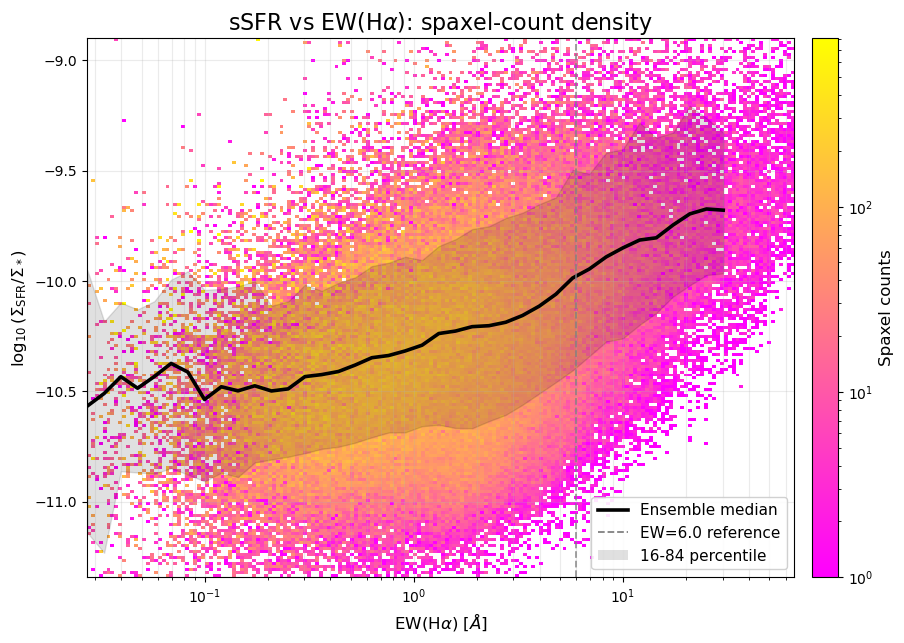


COMPLETED: sSFR vs EW density plot (count-colored)
Included galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694
Skipped galaxies:
  - NGC4698: required file(s) missing
Total usable spaxels used: 847647


In [3]:
# ------------------------------------------------------------------
# sSFR vs EW(H$\alpha$): all-galaxy density view (spaxel-count coloring)
# sSFR is computed as log10(Sigma_SFR / Sigma_*) = logSigmaSFR - logSigmaM
# Color-coded by spaxel counts (log-scale colorbar, spring colormap)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from astropy.io import fits

EW_REF_LINE = 6.0       # visual reference only
LOGEW_BIN_WIDTH = 0.08  # dex in log10(EW)
MIN_BIN_COUNT = 30      # minimum points per EW bin for median trend
HIST_BINS = 180


def load_maps_for_ssfr_ew(gal):
    """Load logSigmaM, logSigmaSFR(HII), and EW(Halpha) maps for one galaxy."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h_spatial:
        log_sigma_m = np.array(h_spatial["LOGMASS_SURFACE_DENSITY"].data, dtype=float)

    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h_gas:
        if "LOGSFR_SURFACE_DENSITY_HII" in h_gas:
            log_sigma_sfr = np.array(h_gas["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float)
        elif "SFR_HII" in h_gas:
            sfr_linear = np.array(h_gas["SFR_HII"].data, dtype=float)
            log_sigma_sfr = np.full_like(sfr_linear, np.nan, dtype=float)
            pos = np.isfinite(sfr_linear) & (sfr_linear > 0)
            log_sigma_sfr[pos] = np.log10(sfr_linear[pos])
        else:
            raise KeyError("Missing HDU LOGSFR_SURFACE_DENSITY_HII (or fallback SFR_HII)")

    with fits.open(f"{gal}_v0.7dev_gas_BIN_maps.fits") as h_ew:
        ew_ha = np.array(h_ew["HA6562_EW"].data, dtype=float)

    if not (log_sigma_m.shape == log_sigma_sfr.shape == ew_ha.shape):
        raise ValueError(
            f"Shape mismatch: logSigmaM={log_sigma_m.shape}, "
            f"logSigmaSFR={log_sigma_sfr.shape}, EW={ew_ha.shape}"
        )

    return log_sigma_m, log_sigma_sfr, ew_ha


def binned_median_logx(x, y, log_bin_width=0.08, min_count=30):
    """Median trend of y in log10(x)-bins. Returns x-bin centers in linear x units."""
    finite = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if np.sum(finite) == 0:
        empty = np.array([])
        return empty, empty, empty, empty, empty

    x_valid = x[finite]
    y_valid = y[finite]
    logx_valid = np.log10(x_valid)

    logx_min = np.nanpercentile(logx_valid, 1)
    logx_max = np.nanpercentile(logx_valid, 99)
    if (not np.isfinite(logx_min)) or (not np.isfinite(logx_max)) or (logx_min >= logx_max):
        empty = np.array([])
        return empty, empty, empty, empty, empty

    start = np.floor(logx_min / log_bin_width) * log_bin_width
    end = np.ceil(logx_max / log_bin_width) * log_bin_width
    edges = np.arange(start, end + log_bin_width, log_bin_width)

    centers, medians, p16, p84, counts = [], [], [], [], []
    for left, right in zip(edges[:-1], edges[1:]):
        in_bin = (logx_valid >= left) & (logx_valid < right)
        n_bin = np.sum(in_bin)
        if n_bin < min_count:
            continue

        y_bin = y_valid[in_bin]
        centers.append(10 ** (0.5 * (left + right)))
        medians.append(np.nanmedian(y_bin))
        p16.append(np.nanpercentile(y_bin, 16))
        p84.append(np.nanpercentile(y_bin, 84))
        counts.append(n_bin)

    return (
        np.array(centers),
        np.array(medians),
        np.array(p16),
        np.array(p84),
        np.array(counts),
    )


# ------------------------------------------------------------------
# Collect all usable spaxels from all galaxies
# ------------------------------------------------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies_all = [f.name.split("_")[0] for f in bins]

if len(galaxies_all) == 0:
    raise FileNotFoundError("No *_SPATIAL_BINNING_maps_extended.fits files found in current directory.")

included_galaxies = []
skipped = []
all_ew = []
all_log_ssfr = []

print("=" * 80)
print("sSFR vs EW(Halpha) density plot (all usable spaxels)")
print("Using finite spaxels with EW > 0 for log-scale x-axis.")
print("=" * 80)

for gal in galaxies_all:
    print(f"\nProcessing {gal} ...")
    spatial_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    ew_file = Path(f"{gal}_v0.7dev_gas_BIN_maps.fits")

    if not (spatial_file.exists() and gas_file.exists() and ew_file.exists()):
        skipped.append((gal, "required file(s) missing"))
        print("  skipped: required file(s) missing")
        continue

    try:
        log_sigma_m, log_sigma_sfr, ew_ha = load_maps_for_ssfr_ew(gal)
    except Exception as e:
        skipped.append((gal, str(e)))
        print(f"  skipped: {e}")
        continue

    log_ssfr = log_sigma_sfr - log_sigma_m
    usable = np.isfinite(log_ssfr) & np.isfinite(ew_ha) & (ew_ha > 0)

    n_use = int(np.sum(usable))
    print(f"  usable spaxels (finite + EW>0): {n_use}")
    if n_use == 0:
        skipped.append((gal, "no usable spaxels after masking"))
        continue

    included_galaxies.append(gal)
    all_ew.append(ew_ha[usable].ravel())
    all_log_ssfr.append(log_ssfr[usable].ravel())

if len(all_ew) == 0:
    raise RuntimeError("No usable spaxels available for plotting.")

all_ew = np.concatenate(all_ew)
all_log_ssfr = np.concatenate(all_log_ssfr)
log_ew = np.log10(all_ew)

# ------------------------------------------------------------------
# 2D histogram colored by spaxel counts
# ------------------------------------------------------------------
x_range_log = (np.nanpercentile(log_ew, 1), np.nanpercentile(log_ew, 99.5))
y_range = (np.nanpercentile(all_log_ssfr, 1), np.nanpercentile(all_log_ssfr, 99.5))

hist, xedges_log, yedges = np.histogram2d(
    log_ew,
    all_log_ssfr,
    bins=HIST_BINS,
    range=[x_range_log, y_range],
)

xedges_lin = 10 ** xedges_log
vmax_counts = float(np.nanmax(hist)) if hist.size else 1.0
if vmax_counts <= 1.0:
    vmax_counts = 2.0

fig, ax = plt.subplots(figsize=(11, 7))
img = ax.pcolormesh(
    xedges_lin,
    yedges,
    np.ma.masked_where(hist.T == 0, hist.T),
    cmap="spring",
    norm=LogNorm(vmin=1, vmax=vmax_counts),
    shading="auto",
)

# Ensemble trend over full usable sample.
cent_e, med_e, p16_e, p84_e, cnt_e = binned_median_logx(
    all_ew,
    all_log_ssfr,
    log_bin_width=LOGEW_BIN_WIDTH,
    min_count=max(MIN_BIN_COUNT * 3, 80),
)
if cent_e.size >= 2:
    ax.plot(cent_e, med_e, color="black", lw=2.6, label="Ensemble median")
    ax.fill_between(cent_e, p16_e, p84_e, color="black", alpha=0.12, label="16-84 percentile")

# Axis formatting
ax.set_xscale("log")
ax.set_xlabel(r"EW(H$\alpha$) [$\AA$]", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\Sigma_{\mathrm{SFR}}/\Sigma_*)$", fontsize=12)
ax.set_title(r"sSFR vs EW(H$\alpha$): spaxel-count density", fontsize=16)
ax.grid(True, alpha=0.25, which="both")
ax.axvline(EW_REF_LINE, color="gray", linestyle="--", lw=1.3, alpha=0.8)

# Colorbar
cbar = fig.colorbar(img, ax=ax, pad=0.02)
cbar.set_label("Spaxel counts", fontsize=12)

# Legend
legend_handles = [
    Line2D([0], [0], color="black", lw=2.6, label="Ensemble median"),
    Line2D([0], [0], color="gray", linestyle="--", lw=1.3, label=f"EW={EW_REF_LINE:.1f} reference"),
    Patch(facecolor="black", edgecolor="none", alpha=0.12, label="16-84 percentile"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=11, framealpha=0.9)

plt.show()

print("\n" + "=" * 80)
print("COMPLETED: sSFR vs EW density plot (count-colored)")
print("=" * 80)
print(f"Included galaxies: {', '.join(included_galaxies)}")
if skipped:
    print("Skipped galaxies:")
    for gal, reason in skipped:
        print(f"  - {gal}: {reason}")
print(f"Total usable spaxels used: {all_ew.size}")

sSFR vs EW(Halpha) colored by log(Sigma_*)
Using finite spaxels with EW > 0 for log-scale x-axis.

Processing IC3392 ...
  usable spaxels (finite + EW>0): 14906

Processing NGC4064 ...
  usable spaxels (finite + EW>0): 7077

Processing NGC4192 ...
  usable spaxels (finite + EW>0): 146165

Processing NGC4293 ...
  usable spaxels (finite + EW>0): 5607

Processing NGC4298 ...
  usable spaxels (finite + EW>0): 156571

Processing NGC4330 ...
  usable spaxels (finite + EW>0): 42956

Processing NGC4383 ...
  usable spaxels (finite + EW>0): 75134

Processing NGC4396 ...
  usable spaxels (finite + EW>0): 81745

Processing NGC4419 ...
  usable spaxels (finite + EW>0): 7386

Processing NGC4457 ...
  usable spaxels (finite + EW>0): 6354

Processing NGC4501 ...
  usable spaxels (finite + EW>0): 261541

Processing NGC4522 ...
  usable spaxels (finite + EW>0): 39619

Processing NGC4694 ...
  usable spaxels (finite + EW>0): 2586

Processing NGC4698 ...
  skipped: required file(s) missing


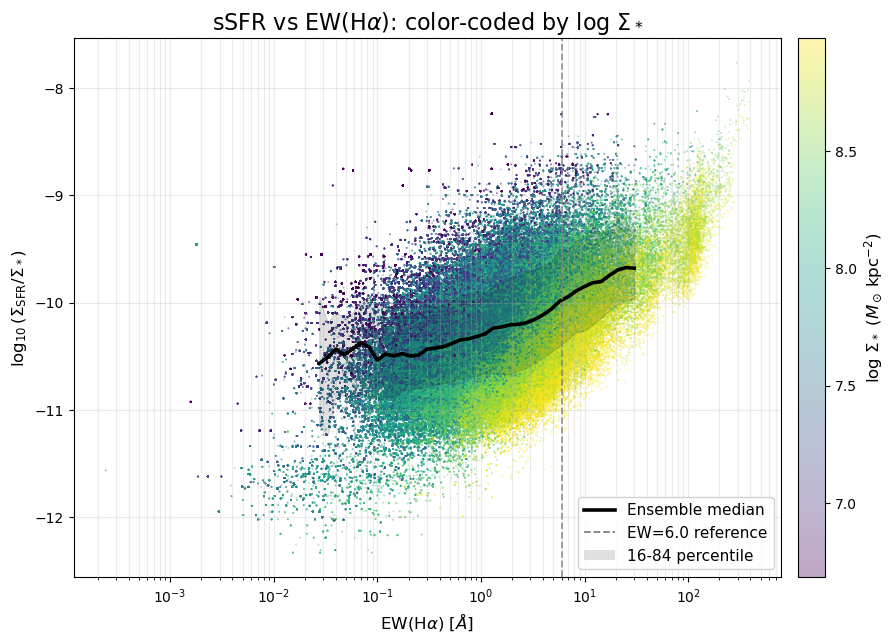


COMPLETED: sSFR vs EW plot (color-coded by log(Sigma_*))
Included galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694
Skipped galaxies:
  - NGC4698: required file(s) missing
Total usable spaxels used: 847647
Color range (1-99 percentile): 6.68 to 8.98


In [4]:
# ------------------------------------------------------------------
# sSFR vs EW(H$\alpha$): all-galaxy view color-coded by log(Sigma_*)
# sSFR is computed as log10(Sigma_SFR / Sigma_*) = logSigmaSFR - logSigmaM
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from astropy.io import fits

EW_REF_LINE = 6.0       # visual reference only
LOGEW_BIN_WIDTH = 0.08  # dex in log10(EW)
MIN_BIN_COUNT = 30      # minimum points per EW bin for median trend


def load_maps_for_ssfr_ew(gal):
    """Load logSigmaM, logSigmaSFR(HII), and EW(Halpha) maps for one galaxy."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h_spatial:
        log_sigma_m = np.array(h_spatial["LOGMASS_SURFACE_DENSITY"].data, dtype=float)

    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h_gas:
        if "LOGSFR_SURFACE_DENSITY_HII" in h_gas:
            log_sigma_sfr = np.array(h_gas["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float)
        elif "SFR_HII" in h_gas:
            sfr_linear = np.array(h_gas["SFR_HII"].data, dtype=float)
            log_sigma_sfr = np.full_like(sfr_linear, np.nan, dtype=float)
            pos = np.isfinite(sfr_linear) & (sfr_linear > 0)
            log_sigma_sfr[pos] = np.log10(sfr_linear[pos])
        else:
            raise KeyError("Missing HDU LOGSFR_SURFACE_DENSITY_HII (or fallback SFR_HII)")

    with fits.open(f"{gal}_v0.7dev_gas_BIN_maps.fits") as h_ew:
        ew_ha = np.array(h_ew["HA6562_EW"].data, dtype=float)

    if not (log_sigma_m.shape == log_sigma_sfr.shape == ew_ha.shape):
        raise ValueError(
            f"Shape mismatch: logSigmaM={log_sigma_m.shape}, "
            f"logSigmaSFR={log_sigma_sfr.shape}, EW={ew_ha.shape}"
        )

    return log_sigma_m, log_sigma_sfr, ew_ha


def binned_median_logx(x, y, log_bin_width=0.08, min_count=30):
    """Median trend of y in log10(x)-bins. Returns x-bin centers in linear x units."""
    finite = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if np.sum(finite) == 0:
        empty = np.array([])
        return empty, empty, empty, empty, empty

    x_valid = x[finite]
    y_valid = y[finite]
    logx_valid = np.log10(x_valid)

    logx_min = np.nanpercentile(logx_valid, 1)
    logx_max = np.nanpercentile(logx_valid, 99)
    if (not np.isfinite(logx_min)) or (not np.isfinite(logx_max)) or (logx_min >= logx_max):
        empty = np.array([])
        return empty, empty, empty, empty, empty

    start = np.floor(logx_min / log_bin_width) * log_bin_width
    end = np.ceil(logx_max / log_bin_width) * log_bin_width
    edges = np.arange(start, end + log_bin_width, log_bin_width)

    centers, medians, p16, p84, counts = [], [], [], [], []
    for left, right in zip(edges[:-1], edges[1:]):
        in_bin = (logx_valid >= left) & (logx_valid < right)
        n_bin = np.sum(in_bin)
        if n_bin < min_count:
            continue

        y_bin = y_valid[in_bin]
        centers.append(10 ** (0.5 * (left + right)))
        medians.append(np.nanmedian(y_bin))
        p16.append(np.nanpercentile(y_bin, 16))
        p84.append(np.nanpercentile(y_bin, 84))
        counts.append(n_bin)

    return (
        np.array(centers),
        np.array(medians),
        np.array(p16),
        np.array(p84),
        np.array(counts),
    )


# ------------------------------------------------------------------
# Collect all usable spaxels from all galaxies
# ------------------------------------------------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies_all = [f.name.split("_")[0] for f in bins]

if len(galaxies_all) == 0:
    raise FileNotFoundError("No *_SPATIAL_BINNING_maps_extended.fits files found in current directory.")

included_galaxies = []
skipped = []
all_ew = []
all_log_ssfr = []
all_log_sigma_m = []

print("=" * 80)
print("sSFR vs EW(Halpha) colored by log(Sigma_*)")
print("Using finite spaxels with EW > 0 for log-scale x-axis.")
print("=" * 80)

for gal in galaxies_all:
    print(f"\nProcessing {gal} ...")
    spatial_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    ew_file = Path(f"{gal}_v0.7dev_gas_BIN_maps.fits")

    if not (spatial_file.exists() and gas_file.exists() and ew_file.exists()):
        skipped.append((gal, "required file(s) missing"))
        print("  skipped: required file(s) missing")
        continue

    try:
        log_sigma_m, log_sigma_sfr, ew_ha = load_maps_for_ssfr_ew(gal)
    except Exception as e:
        skipped.append((gal, str(e)))
        print(f"  skipped: {e}")
        continue

    log_ssfr = log_sigma_sfr - log_sigma_m
    usable = np.isfinite(log_sigma_m) & np.isfinite(log_ssfr) & np.isfinite(ew_ha) & (ew_ha > 0)

    n_use = int(np.sum(usable))
    print(f"  usable spaxels (finite + EW>0): {n_use}")
    if n_use == 0:
        skipped.append((gal, "no usable spaxels after masking"))
        continue

    included_galaxies.append(gal)
    all_ew.append(ew_ha[usable].ravel())
    all_log_ssfr.append(log_ssfr[usable].ravel())
    all_log_sigma_m.append(log_sigma_m[usable].ravel())

if len(all_ew) == 0:
    raise RuntimeError("No usable spaxels available for plotting.")

all_ew = np.concatenate(all_ew)
all_log_ssfr = np.concatenate(all_log_ssfr)
all_log_sigma_m = np.concatenate(all_log_sigma_m)

# ------------------------------------------------------------------
# Scatter plot color-coded by log(Sigma_*)
# ------------------------------------------------------------------
vmin_sig = np.nanpercentile(all_log_sigma_m, 1)
vmax_sig = np.nanpercentile(all_log_sigma_m, 99)
if not np.isfinite(vmin_sig) or not np.isfinite(vmax_sig) or vmin_sig >= vmax_sig:
    vmin_sig, vmax_sig = np.nanmin(all_log_sigma_m), np.nanmax(all_log_sigma_m)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    all_ew,
    all_log_ssfr,
    c=all_log_sigma_m,
    cmap="viridis",
    norm=Normalize(vmin=vmin_sig, vmax=vmax_sig),
    s=2,
    alpha=0.35,
    linewidths=0,
    rasterized=True,
)

# Ensemble trend over full usable sample.
cent_e, med_e, p16_e, p84_e, cnt_e = binned_median_logx(
    all_ew,
    all_log_ssfr,
    log_bin_width=LOGEW_BIN_WIDTH,
    min_count=max(MIN_BIN_COUNT * 3, 80),
)
if cent_e.size >= 2:
    ax.plot(cent_e, med_e, color="black", lw=2.6, label="Ensemble median")
    ax.fill_between(cent_e, p16_e, p84_e, color="black", alpha=0.12, label="16-84 percentile")

# Axis formatting
ax.set_xscale("log")
ax.set_xlabel(r"EW(H$\alpha$) [$\AA$]", fontsize=12)
ax.set_ylabel(r"$\log_{10}(\Sigma_{\mathrm{SFR}}/\Sigma_*)$", fontsize=12)
ax.set_title(r"sSFR vs EW(H$\alpha$): color-coded by $\log\,\Sigma_*$", fontsize=16)
ax.grid(True, alpha=0.25, which="both")
ax.axvline(EW_REF_LINE, color="gray", linestyle="--", lw=1.3, alpha=0.8)

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$\log\,\Sigma_*\ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)

# Legend
legend_handles = [
    Line2D([0], [0], color="black", lw=2.6, label="Ensemble median"),
    Line2D([0], [0], color="gray", linestyle="--", lw=1.3, label=f"EW={EW_REF_LINE:.1f} reference"),
    Patch(facecolor="black", edgecolor="none", alpha=0.12, label="16-84 percentile"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=11, framealpha=0.9)

plt.show()

print("\n" + "=" * 80)
print("COMPLETED: sSFR vs EW plot (color-coded by log(Sigma_*))")
print("=" * 80)
print(f"Included galaxies: {', '.join(included_galaxies)}")
if skipped:
    print("Skipped galaxies:")
    for gal, reason in skipped:
        print(f"  - {gal}: {reason}")
print(f"Total usable spaxels used: {all_ew.size}")
print(f"Color range (1-99 percentile): {vmin_sig:.2f} to {vmax_sig:.2f}")

Stellar mass vs EW(Halpha) color-coded by sSFR
Using finite spaxels with EW > 0 for log-scale x-axis.

Processing IC3392 ...
  usable spaxels (finite + EW>0): 14906

Processing NGC4064 ...
  usable spaxels (finite + EW>0): 7077

Processing NGC4192 ...
  usable spaxels (finite + EW>0): 146165

Processing NGC4293 ...
  usable spaxels (finite + EW>0): 5607

Processing NGC4298 ...
  usable spaxels (finite + EW>0): 156571

Processing NGC4330 ...
  usable spaxels (finite + EW>0): 42956

Processing NGC4383 ...
  usable spaxels (finite + EW>0): 75134

Processing NGC4396 ...
  usable spaxels (finite + EW>0): 81745

Processing NGC4419 ...
  usable spaxels (finite + EW>0): 7386

Processing NGC4457 ...
  usable spaxels (finite + EW>0): 6354

Processing NGC4501 ...
  usable spaxels (finite + EW>0): 261541

Processing NGC4522 ...
  usable spaxels (finite + EW>0): 39619

Processing NGC4694 ...
  usable spaxels (finite + EW>0): 2586

Processing NGC4698 ...
  skipped: required file(s) missing


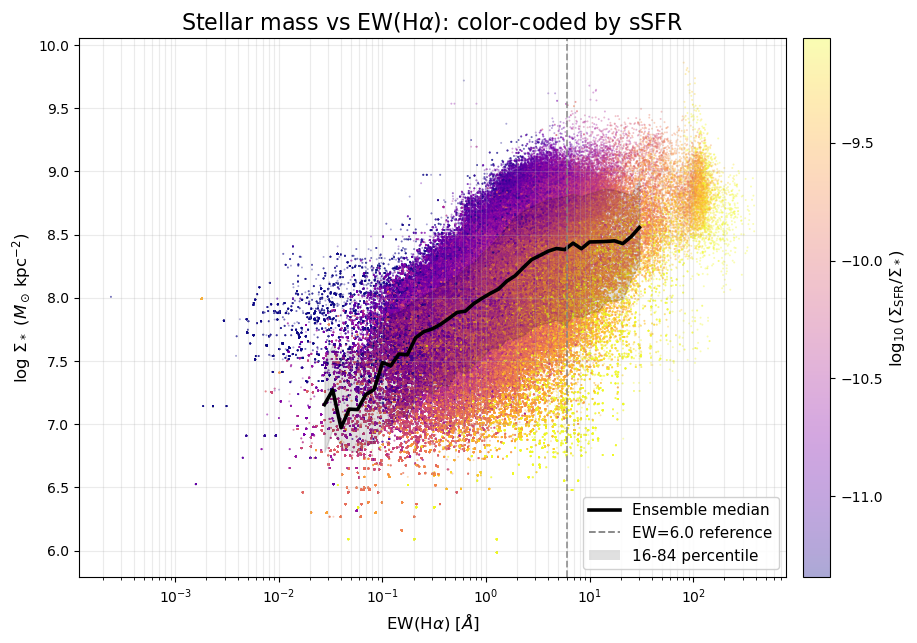


COMPLETED: Stellar mass vs EW plot (color-coded by sSFR)
Included galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694
Skipped galaxies:
  - NGC4698: required file(s) missing
Total usable spaxels used: 847647
Color range (1-99 percentile): -11.34 to -9.06


In [5]:
# ------------------------------------------------------------------
# Stellar mass vs EW(H$\alpha$): all-galaxy view color-coded by sSFR
# sSFR is computed as log10(Sigma_SFR / Sigma_*) = logSigmaSFR - logSigmaM
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from astropy.io import fits

EW_REF_LINE = 6.0       # visual reference only
LOGEW_BIN_WIDTH = 0.08  # dex in log10(EW)
MIN_BIN_COUNT = 30      # minimum points per EW bin for median trend


def load_maps_for_ssfr_ew(gal):
    """Load logSigmaM, logSigmaSFR(HII), and EW(Halpha) maps for one galaxy."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h_spatial:
        log_sigma_m = np.array(h_spatial["LOGMASS_SURFACE_DENSITY"].data, dtype=float)

    with fits.open(f"{gal}_gas_BIN_maps_extended.fits") as h_gas:
        if "LOGSFR_SURFACE_DENSITY_HII" in h_gas:
            log_sigma_sfr = np.array(h_gas["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float)
        elif "SFR_HII" in h_gas:
            sfr_linear = np.array(h_gas["SFR_HII"].data, dtype=float)
            log_sigma_sfr = np.full_like(sfr_linear, np.nan, dtype=float)
            pos = np.isfinite(sfr_linear) & (sfr_linear > 0)
            log_sigma_sfr[pos] = np.log10(sfr_linear[pos])
        else:
            raise KeyError("Missing HDU LOGSFR_SURFACE_DENSITY_HII (or fallback SFR_HII)")

    with fits.open(f"{gal}_v0.7dev_gas_BIN_maps.fits") as h_ew:
        ew_ha = np.array(h_ew["HA6562_EW"].data, dtype=float)

    if not (log_sigma_m.shape == log_sigma_sfr.shape == ew_ha.shape):
        raise ValueError(
            f"Shape mismatch: logSigmaM={log_sigma_m.shape}, "
            f"logSigmaSFR={log_sigma_sfr.shape}, EW={ew_ha.shape}"
        )

    return log_sigma_m, log_sigma_sfr, ew_ha


def binned_median_logx(x, y, log_bin_width=0.08, min_count=30):
    """Median trend of y in log10(x)-bins. Returns x-bin centers in linear x units."""
    finite = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if np.sum(finite) == 0:
        empty = np.array([])
        return empty, empty, empty, empty, empty

    x_valid = x[finite]
    y_valid = y[finite]
    logx_valid = np.log10(x_valid)

    logx_min = np.nanpercentile(logx_valid, 1)
    logx_max = np.nanpercentile(logx_valid, 99)
    if (not np.isfinite(logx_min)) or (not np.isfinite(logx_max)) or (logx_min >= logx_max):
        empty = np.array([])
        return empty, empty, empty, empty, empty

    start = np.floor(logx_min / log_bin_width) * log_bin_width
    end = np.ceil(logx_max / log_bin_width) * log_bin_width
    edges = np.arange(start, end + log_bin_width, log_bin_width)

    centers, medians, p16, p84, counts = [], [], [], [], []
    for left, right in zip(edges[:-1], edges[1:]):
        in_bin = (logx_valid >= left) & (logx_valid < right)
        n_bin = np.sum(in_bin)
        if n_bin < min_count:
            continue

        y_bin = y_valid[in_bin]
        centers.append(10 ** (0.5 * (left + right)))
        medians.append(np.nanmedian(y_bin))
        p16.append(np.nanpercentile(y_bin, 16))
        p84.append(np.nanpercentile(y_bin, 84))
        counts.append(n_bin)

    return (
        np.array(centers),
        np.array(medians),
        np.array(p16),
        np.array(p84),
        np.array(counts),
    )


# ------------------------------------------------------------------
# Collect all usable spaxels from all galaxies
# ------------------------------------------------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies_all = [f.name.split("_")[0] for f in bins]

if len(galaxies_all) == 0:
    raise FileNotFoundError("No *_SPATIAL_BINNING_maps_extended.fits files found in current directory.")

included_galaxies = []
skipped = []
all_ew = []
all_log_sigma_m = []
all_log_ssfr = []

print("=" * 80)
print("Stellar mass vs EW(Halpha) color-coded by sSFR")
print("Using finite spaxels with EW > 0 for log-scale x-axis.")
print("=" * 80)

for gal in galaxies_all:
    print(f"\nProcessing {gal} ...")
    spatial_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    ew_file = Path(f"{gal}_v0.7dev_gas_BIN_maps.fits")

    if not (spatial_file.exists() and gas_file.exists() and ew_file.exists()):
        skipped.append((gal, "required file(s) missing"))
        print("  skipped: required file(s) missing")
        continue

    try:
        log_sigma_m, log_sigma_sfr, ew_ha = load_maps_for_ssfr_ew(gal)
    except Exception as e:
        skipped.append((gal, str(e)))
        print(f"  skipped: {e}")
        continue

    log_ssfr = log_sigma_sfr - log_sigma_m
    usable = np.isfinite(log_sigma_m) & np.isfinite(log_ssfr) & np.isfinite(ew_ha) & (ew_ha > 0)

    n_use = int(np.sum(usable))
    print(f"  usable spaxels (finite + EW>0): {n_use}")
    if n_use == 0:
        skipped.append((gal, "no usable spaxels after masking"))
        continue

    included_galaxies.append(gal)
    all_ew.append(ew_ha[usable].ravel())
    all_log_sigma_m.append(log_sigma_m[usable].ravel())
    all_log_ssfr.append(log_ssfr[usable].ravel())

if len(all_ew) == 0:
    raise RuntimeError("No usable spaxels available for plotting.")

all_ew = np.concatenate(all_ew)
all_log_sigma_m = np.concatenate(all_log_sigma_m)
all_log_ssfr = np.concatenate(all_log_ssfr)

# ------------------------------------------------------------------
# Scatter plot color-coded by sSFR
# ------------------------------------------------------------------
vmin_ssfr = np.nanpercentile(all_log_ssfr, 1)
vmax_ssfr = np.nanpercentile(all_log_ssfr, 99)
if not np.isfinite(vmin_ssfr) or not np.isfinite(vmax_ssfr) or vmin_ssfr >= vmax_ssfr:
    vmin_ssfr, vmax_ssfr = np.nanmin(all_log_ssfr), np.nanmax(all_log_ssfr)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    all_ew,
    all_log_sigma_m,
    c=all_log_ssfr,
    cmap="plasma",
    norm=Normalize(vmin=vmin_ssfr, vmax=vmax_ssfr),
    s=2,
    alpha=0.35,
    linewidths=0,
    rasterized=True,
)

# Ensemble trend over full usable sample.
cent_e, med_e, p16_e, p84_e, cnt_e = binned_median_logx(
    all_ew,
    all_log_sigma_m,
    log_bin_width=LOGEW_BIN_WIDTH,
    min_count=max(MIN_BIN_COUNT * 3, 80),
)
if cent_e.size >= 2:
    ax.plot(cent_e, med_e, color="black", lw=2.6, label="Ensemble median")
    ax.fill_between(cent_e, p16_e, p84_e, color="black", alpha=0.12, label="16-84 percentile")

# Axis formatting
ax.set_xscale("log")
ax.set_xlabel(r"EW(H$\alpha$) [$\AA$]", fontsize=12)
ax.set_ylabel(r"$\log\,\Sigma_*\ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax.set_title(r"Stellar mass vs EW(H$\alpha$): color-coded by sSFR", fontsize=16)
ax.grid(True, alpha=0.25, which="both")
ax.axvline(EW_REF_LINE, color="gray", linestyle="--", lw=1.3, alpha=0.8)

# Colorbar
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$\log_{10}(\Sigma_{\mathrm{SFR}}/\Sigma_*)$", fontsize=12)

# Legend
legend_handles = [
    Line2D([0], [0], color="black", lw=2.6, label="Ensemble median"),
    Line2D([0], [0], color="gray", linestyle="--", lw=1.3, label=f"EW={EW_REF_LINE:.1f} reference"),
    Patch(facecolor="black", edgecolor="none", alpha=0.12, label="16-84 percentile"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=11, framealpha=0.9)

plt.show()

print("\n" + "=" * 80)
print("COMPLETED: Stellar mass vs EW plot (color-coded by sSFR)")
print("=" * 80)
print(f"Included galaxies: {', '.join(included_galaxies)}")
if skipped:
    print("Skipped galaxies:")
    for gal, reason in skipped:
        print(f"  - {gal}: {reason}")
print(f"Total usable spaxels used: {all_ew.size}")
print(f"Color range (1-99 percentile): {vmin_ssfr:.2f} to {vmax_ssfr:.2f}")

Stellar mass vs EW(Halpha) density plot (all usable spaxels)
Using finite spaxels with EW > 0 for log-scale x-axis.

Processing IC3392 ...
  usable spaxels (finite + EW>0): 73168

Processing NGC4064 ...
  usable spaxels (finite + EW>0): 157495

Processing NGC4192 ...
  usable spaxels (finite + EW>0): 489332

Processing NGC4293 ...
  usable spaxels (finite + EW>0): 250242

Processing NGC4298 ...
  usable spaxels (finite + EW>0): 349752

Processing NGC4330 ...
  usable spaxels (finite + EW>0): 155066

Processing NGC4383 ...
  usable spaxels (finite + EW>0): 129124

Processing NGC4396 ...
  usable spaxels (finite + EW>0): 158835

Processing NGC4419 ...
  usable spaxels (finite + EW>0): 154532

Processing NGC4457 ...
  usable spaxels (finite + EW>0): 259347

Processing NGC4501 ...
  usable spaxels (finite + EW>0): 644712

Processing NGC4522 ...
  usable spaxels (finite + EW>0): 117352

Processing NGC4694 ...
  usable spaxels (finite + EW>0): 82871

Processing NGC4698 ...
  skipped: require

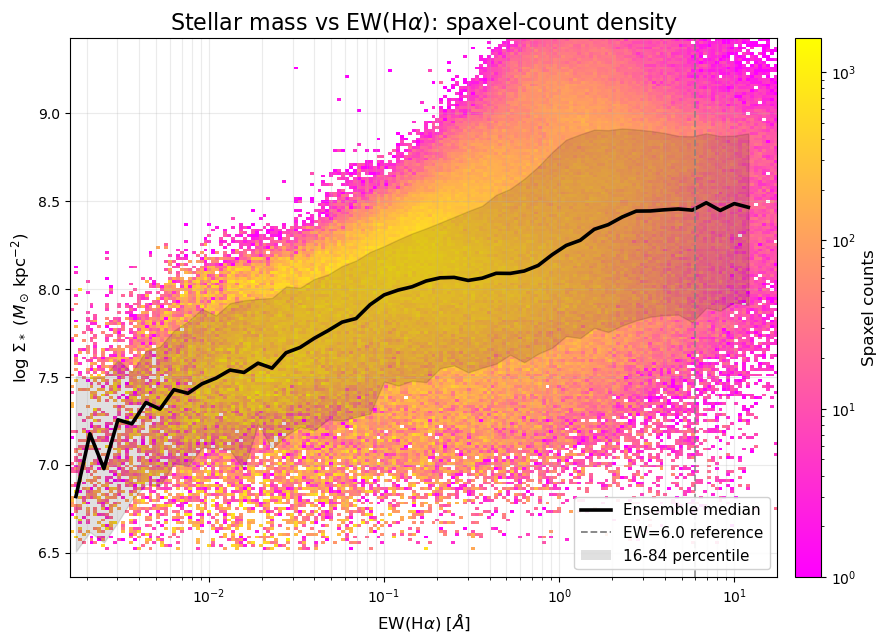


COMPLETED: Stellar mass vs EW density plot (count-colored)
Included galaxies: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694
Skipped galaxies:
  - NGC4698: required file(s) missing
Total usable spaxels used: 3021828


In [6]:
# ------------------------------------------------------------------
# Stellar mass vs EW(H$\alpha$): all-galaxy density view (spaxel-count coloring)
# Color-coded by spaxel counts (log-scale colorbar, spring colormap)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
from astropy.io import fits

EW_REF_LINE = 6.0       # visual reference only
LOGEW_BIN_WIDTH = 0.08  # dex in log10(EW)
MIN_BIN_COUNT = 30      # minimum points per EW bin for median trend
HIST_BINS = 180


def load_maps_for_mass_ew(gal):
    """Load logSigmaM and EW(Halpha) maps for one galaxy."""
    with fits.open(f"{gal}_SPATIAL_BINNING_maps_extended.fits") as h_spatial:
        log_sigma_m = np.array(h_spatial["LOGMASS_SURFACE_DENSITY"].data, dtype=float)

    with fits.open(f"{gal}_v0.7dev_gas_BIN_maps.fits") as h_ew:
        ew_ha = np.array(h_ew["HA6562_EW"].data, dtype=float)

    if log_sigma_m.shape != ew_ha.shape:
        raise ValueError(f"Shape mismatch: logSigmaM={log_sigma_m.shape}, EW={ew_ha.shape}")

    return log_sigma_m, ew_ha


def binned_median_logx(x, y, log_bin_width=0.08, min_count=30):
    """Median trend of y in log10(x)-bins. Returns x-bin centers in linear x units."""
    finite = np.isfinite(x) & np.isfinite(y) & (x > 0)
    if np.sum(finite) == 0:
        empty = np.array([])
        return empty, empty, empty, empty, empty

    x_valid = x[finite]
    y_valid = y[finite]
    logx_valid = np.log10(x_valid)

    logx_min = np.nanpercentile(logx_valid, 1)
    logx_max = np.nanpercentile(logx_valid, 99)
    if (not np.isfinite(logx_min)) or (not np.isfinite(logx_max)) or (logx_min >= logx_max):
        empty = np.array([])
        return empty, empty, empty, empty, empty

    start = np.floor(logx_min / log_bin_width) * log_bin_width
    end = np.ceil(logx_max / log_bin_width) * log_bin_width
    edges = np.arange(start, end + log_bin_width, log_bin_width)

    centers, medians, p16, p84, counts = [], [], [], [], []
    for left, right in zip(edges[:-1], edges[1:]):
        in_bin = (logx_valid >= left) & (logx_valid < right)
        n_bin = np.sum(in_bin)
        if n_bin < min_count:
            continue

        y_bin = y_valid[in_bin]
        centers.append(10 ** (0.5 * (left + right)))
        medians.append(np.nanmedian(y_bin))
        p16.append(np.nanpercentile(y_bin, 16))
        p84.append(np.nanpercentile(y_bin, 84))
        counts.append(n_bin)

    return (
        np.array(centers),
        np.array(medians),
        np.array(p16),
        np.array(p84),
        np.array(counts),
    )


# ------------------------------------------------------------------
# Collect all usable spaxels from all galaxies
# ------------------------------------------------------------------
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies_all = [f.name.split("_")[0] for f in bins]

if len(galaxies_all) == 0:
    raise FileNotFoundError("No *_SPATIAL_BINNING_maps_extended.fits files found in current directory.")

included_galaxies = []
skipped = []
all_ew = []
all_log_sigma_m = []

print("=" * 80)
print("Stellar mass vs EW(Halpha) density plot (all usable spaxels)")
print("Using finite spaxels with EW > 0 for log-scale x-axis.")
print("=" * 80)

for gal in galaxies_all:
    print(f"\nProcessing {gal} ...")
    spatial_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    ew_file = Path(f"{gal}_v0.7dev_gas_BIN_maps.fits")

    if not (spatial_file.exists() and ew_file.exists()):
        skipped.append((gal, "required file(s) missing"))
        print("  skipped: required file(s) missing")
        continue

    try:
        log_sigma_m, ew_ha = load_maps_for_mass_ew(gal)
    except Exception as e:
        skipped.append((gal, str(e)))
        print(f"  skipped: {e}")
        continue

    usable = np.isfinite(log_sigma_m) & np.isfinite(ew_ha) & (ew_ha > 0)

    n_use = int(np.sum(usable))
    print(f"  usable spaxels (finite + EW>0): {n_use}")
    if n_use == 0:
        skipped.append((gal, "no usable spaxels after masking"))
        continue

    included_galaxies.append(gal)
    all_ew.append(ew_ha[usable].ravel())
    all_log_sigma_m.append(log_sigma_m[usable].ravel())

if len(all_ew) == 0:
    raise RuntimeError("No usable spaxels available for plotting.")

all_ew = np.concatenate(all_ew)
all_log_sigma_m = np.concatenate(all_log_sigma_m)
log_ew = np.log10(all_ew)

# ------------------------------------------------------------------
# 2D histogram colored by spaxel counts
# ------------------------------------------------------------------
x_range_log = (np.nanpercentile(log_ew, 1), np.nanpercentile(log_ew, 99.5))
y_range = (np.nanpercentile(all_log_sigma_m, 1), np.nanpercentile(all_log_sigma_m, 99.5))

hist, xedges_log, yedges = np.histogram2d(
    log_ew,
    all_log_sigma_m,
    bins=HIST_BINS,
    range=[x_range_log, y_range],
)

xedges_lin = 10 ** xedges_log
vmax_counts = float(np.nanmax(hist)) if hist.size else 1.0
if vmax_counts <= 1.0:
    vmax_counts = 2.0

fig, ax = plt.subplots(figsize=(11, 7))
img = ax.pcolormesh(
    xedges_lin,
    yedges,
    np.ma.masked_where(hist.T == 0, hist.T),
    cmap="spring",
    norm=LogNorm(vmin=1, vmax=vmax_counts),
    shading="auto",
)

# Ensemble trend over full usable sample.
cent_e, med_e, p16_e, p84_e, cnt_e = binned_median_logx(
    all_ew,
    all_log_sigma_m,
    log_bin_width=LOGEW_BIN_WIDTH,
    min_count=max(MIN_BIN_COUNT * 3, 80),
)
if cent_e.size >= 2:
    ax.plot(cent_e, med_e, color="black", lw=2.6, label="Ensemble median")
    ax.fill_between(cent_e, p16_e, p84_e, color="black", alpha=0.12, label="16-84 percentile")

# Axis formatting
ax.set_xscale("log")
ax.set_xlabel(r"EW(H$\alpha$) [$\AA$]", fontsize=12)
ax.set_ylabel(r"$\log\,\Sigma_*\ (M_\odot\,\mathrm{kpc}^{-2})$", fontsize=12)
ax.set_title(r"Stellar mass vs EW(H$\alpha$): spaxel-count density", fontsize=16)
ax.grid(True, alpha=0.25, which="both")
ax.axvline(EW_REF_LINE, color="gray", linestyle="--", lw=1.3, alpha=0.8)

# Colorbar
cbar = fig.colorbar(img, ax=ax, pad=0.02)
cbar.set_label("Spaxel counts", fontsize=12)

# Legend
legend_handles = [
    Line2D([0], [0], color="black", lw=2.6, label="Ensemble median"),
    Line2D([0], [0], color="gray", linestyle="--", lw=1.3, label=f"EW={EW_REF_LINE:.1f} reference"),
    Patch(facecolor="black", edgecolor="none", alpha=0.12, label="16-84 percentile"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=11, framealpha=0.9)

plt.show()

print("\n" + "=" * 80)
print("COMPLETED: Stellar mass vs EW density plot (count-colored)")
print("=" * 80)
print(f"Included galaxies: {', '.join(included_galaxies)}")
if skipped:
    print("Skipped galaxies:")
    for gal, reason in skipped:
        print(f"  - {gal}: {reason}")
print(f"Total usable spaxels used: {all_ew.size}")

  IC3392: 49984 valid spaxels (flux+SFR+EW>0 mask)
  NGC4064: 111655 valid spaxels (flux+SFR+EW>0 mask)
  NGC4192: 458926 valid spaxels (flux+SFR+EW>0 mask)
  NGC4293: 141121 valid spaxels (flux+SFR+EW>0 mask)
  NGC4298: 277437 valid spaxels (flux+SFR+EW>0 mask)
  NGC4330: 88422 valid spaxels (flux+SFR+EW>0 mask)
  NGC4383: 127766 valid spaxels (flux+SFR+EW>0 mask)
  NGC4396: 155963 valid spaxels (flux+SFR+EW>0 mask)
  NGC4419: 126952 valid spaxels (flux+SFR+EW>0 mask)
  NGC4457: 227739 valid spaxels (flux+SFR+EW>0 mask)
  NGC4501: 578505 valid spaxels (flux+SFR+EW>0 mask)
  NGC4522: 82325 valid spaxels (flux+SFR+EW>0 mask)
  NGC4694: 59616 valid spaxels (flux+SFR+EW>0 mask)
  NGC4698: Data files not found

Total combined valid spaxels (flux+SFR+EW>0 mask): 2486411

SFR component counts (finite spaxels, all galaxies combined):
  HII: 847826 (33.776%)
  NONHII: 1504464 (59.935%)
  UNCLASSIFIED2: 157882 (6.290%)

SF component counts (finite spaxels, all galaxies combined):
  SF: 1217809 

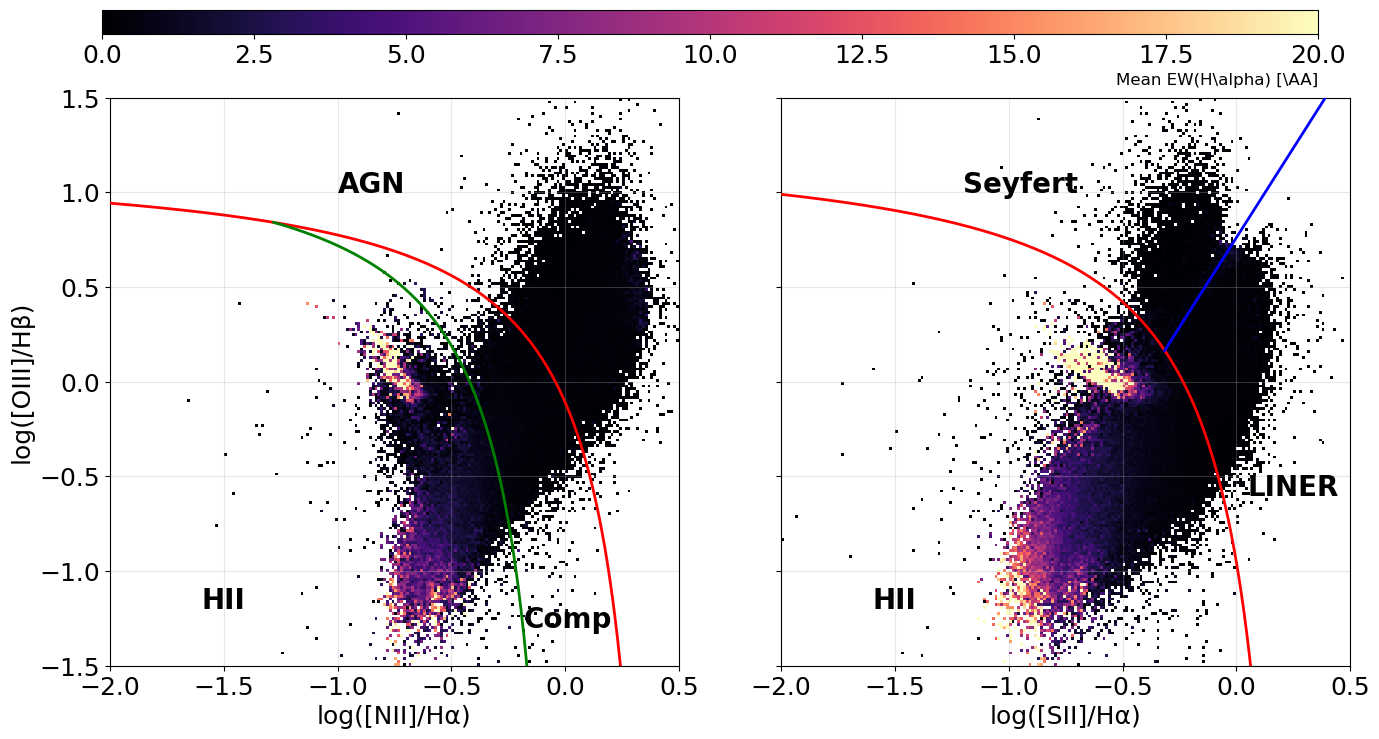


Successfully created combined NII/SII diagrams color-coded by EW(Halpha)
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4383, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Color quantity: mean EW(Halpha) in each BPT bin (linear scale, colorbar 0-20); bins with <3 spaxels are masked


In [7]:
# ------------------------------------------------------------------
# Combined Analysis: NII and SII diagrams - color-coded by EW(Halpha)
# Collect all spaxels from all galaxies (no HII-only selection)
# Use only dust-corrected emission line fluxes; no O/H needed
# Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII,
#                  LOGSFR_SURFACE_DENSITY_NONHII, or LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2
# Color each BPT bin by mean EW(Halpha) in linear scale
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits


# BPT reference line functions (for drawing curves only)
def kewley01_N2(x):
    return 0.61 / (x - 0.47) + 1.19


def kauff03_N2(x):
    return 0.61 / (x - 0.05) + 1.30


def kewley01_S2(x):
    return 0.72 / (x - 0.32) + 1.30


def kewley06_Sy_LIN(x):
    return 1.89 * x + 0.76


def bpt_error_propagation(numerator, denominator, numerator_err, denominator_err):
    with np.errstate(divide="ignore", invalid="ignore"):
        log_ratio_err = 1 / (np.log(10)) * np.sqrt(
            (numerator_err / numerator) ** 2 + (denominator_err / denominator) ** 2
        )
        return log_ratio_err


# Create x arrays for reference lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286 - np.sqrt(2871561)) / 1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159 - np.sqrt(105081)) / 525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path(".").glob("*_SPATIAL_BINNING_maps_extended.fits"))
galaxies = [f.name.split("_")[0] for f in bins]


# Collect all spaxels from all galaxies (no HII selection)
all_logN2 = []
all_logO3 = []
all_logS2 = []
all_ew = []

# Stats for SFR components
count_hii = 0
count_nonhii = 0
count_unclass = 0
count_union = 0
sum_check_total = 0
sum_check_ok = 0
sum_check_maxabs = []

# Stats for SF/NONSF/UNCLASSIFIED1 components
count_sf = 0
count_nonsf = 0
count_unclass1 = 0
count_union_sf = 0

# Error arrays for spaxel subsets
err_hii_logN2, err_hii_logS2, err_hii_logO3 = [], [], []
err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3 = [], [], []
err_unclass_logN2, err_unclass_logS2, err_unclass_logO3 = [], [], []
err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3 = [], [], []
err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3 = [], [], []

print("Collecting all spaxels from all galaxies (corrected flux + SFR mask + EW>0)...")
for gal in galaxies:
    gas_file = Path(f"{gal}_gas_BIN_maps_extended.fits")
    bin_file = Path(f"{gal}_SPATIAL_BINNING_maps_extended.fits")
    ew_file = Path(f"{gal}_v0.7dev_gas_BIN_maps.fits")

    if gas_file.exists() and bin_file.exists() and ew_file.exists():
        with fits.open(gas_file) as h:
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h["HB4861_FLUX_CORR"].data
            HA6562_FLUX_corr = h["HA6562_FLUX_CORR"].data
            OIII5006_FLUX_corr = h["OIII5006_FLUX_CORR"].data
            NII6583_FLUX_corr = h["NII6583_FLUX_CORR"].data
            SII6716_FLUX_corr = h["SII6716_FLUX_CORR"].data
            SII6730_FLUX_corr = h["SII6730_FLUX_CORR"].data

            # Load corrected emission line flux errors
            HB4861_FLUX_ERR = h["HB4861_FLUX_ERR"].data
            HA6562_FLUX_ERR = h["HA6562_FLUX_ERR"].data
            OIII5006_FLUX_ERR = h["OIII5006_FLUX_ERR"].data
            NII6583_FLUX_ERR = h["NII6583_FLUX_ERR"].data
            SII6716_FLUX_ERR = h["SII6716_FLUX_ERR"].data
            SII6730_FLUX_ERR = h["SII6730_FLUX_ERR"].data

            # Load SFR surface density maps
            logSigmaSFR_HII = h["LOGSFR_SURFACE_DENSITY_HII"].data
            logSigmaSFR_NONHII = h["LOGSFR_SURFACE_DENSITY_NONHII"].data
            logSigmaSFR_UNCLASS = h["LOGSFR_SURFACE_DENSITY_UNCLASSIFIED2"].data
            logSigmaSFR_TOTAL = h["LOGSFR_SURFACE_DENSITY"].data

            # Load SF / NONSF / UNCLASSIFIED1 maps
            logSigmaSFR_SF = h["LOGSFR_SURFACE_DENSITY_SF"].data
            logSigmaSFR_NONSF = h["LOGSFR_SURFACE_DENSITY_NONSF"].data
            logSigmaSFR_UNCLASS1 = h["LOGSFR_SURFACE_DENSITY_UNCLASSIFIED1"].data

        with fits.open(ew_file) as h_ew:
            if "HA6562_EW" not in h_ew:
                print(f"  {gal}: missing HA6562_EW, skipped")
                continue
            ew_ha = h_ew["HA6562_EW"].data

        if ew_ha.shape != HA6562_FLUX_corr.shape:
            print(f"  {gal}: EW shape mismatch, skipped")
            continue

        # SFR masks
        hii_mask = np.isfinite(logSigmaSFR_HII)
        nonhii_mask = np.isfinite(logSigmaSFR_NONHII)
        unclass_mask = np.isfinite(logSigmaSFR_UNCLASS)
        total_mask = np.isfinite(logSigmaSFR_TOTAL)
        union_mask = hii_mask | nonhii_mask | unclass_mask

        count_hii += np.sum(hii_mask)
        count_nonhii += np.sum(nonhii_mask)
        count_unclass += np.sum(unclass_mask)
        count_union += np.sum(union_mask)

        # SF / NONSF / UNCLASSIFIED1 masks
        sf_mask = np.isfinite(logSigmaSFR_SF)
        nonsf_mask = np.isfinite(logSigmaSFR_NONSF)
        unclass1_mask = np.isfinite(logSigmaSFR_UNCLASS1)
        union_sf_mask = sf_mask | nonsf_mask | unclass1_mask

        count_sf += np.sum(sf_mask)
        count_nonsf += np.sum(nonsf_mask)
        count_unclass1 += np.sum(unclass1_mask)
        count_union_sf += np.sum(union_sf_mask)

        # Check add-up consistency where all components and total are finite
        sum_mask = hii_mask & nonhii_mask & unclass_mask & total_mask
        if np.any(sum_mask):
            diff = logSigmaSFR_TOTAL[sum_mask] - (
                logSigmaSFR_HII[sum_mask] + logSigmaSFR_NONHII[sum_mask] + logSigmaSFR_UNCLASS[sum_mask]
            )
            sum_check_total += diff.size
            sum_check_ok += np.sum(np.isclose(diff, 0.0, atol=1e-6, rtol=0))
            sum_check_maxabs.append(np.nanmax(np.abs(diff)))

        # Valid where all corrected line fluxes are finite and positive
        flux_mask = (
            np.isfinite(HB4861_FLUX_corr)
            & (HB4861_FLUX_corr > 0)
            & np.isfinite(HA6562_FLUX_corr)
            & (HA6562_FLUX_corr > 0)
            & np.isfinite(OIII5006_FLUX_corr)
            & (OIII5006_FLUX_corr > 0)
            & np.isfinite(NII6583_FLUX_corr)
            & (NII6583_FLUX_corr > 0)
            & np.isfinite(SII6716_FLUX_corr)
            & (SII6716_FLUX_corr > 0)
            & np.isfinite(SII6730_FLUX_corr)
            & (SII6730_FLUX_corr > 0)
        )

        # SFR mask: keep spaxels where any class is finite
        sfr_mask = union_mask

        # EW mask for color quantity
        ew_mask = np.isfinite(ew_ha) & (ew_ha > 0)

        # Combined mask for plotting
        valid_mask = flux_mask & sfr_mask & ew_mask
        n_pixels = int(np.sum(valid_mask))
        print(f"  {gal}: {n_pixels} valid spaxels (flux+SFR+EW>0 mask)")

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]
        EW_common = ew_ha[valid_mask]

        # Calculate line ratios for all valid spaxels
        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.extend(logN2.ravel())
        all_logO3.extend(logO3.ravel())
        all_logS2.extend(logS2.ravel())
        all_ew.extend(EW_common.ravel())

        # Error propagation for spaxel subsets
        err_mask = (
            np.isfinite(HB4861_FLUX_ERR)
            & (HB4861_FLUX_ERR > 0)
            & np.isfinite(HA6562_FLUX_ERR)
            & (HA6562_FLUX_ERR > 0)
            & np.isfinite(OIII5006_FLUX_ERR)
            & (OIII5006_FLUX_ERR > 0)
            & np.isfinite(NII6583_FLUX_ERR)
            & (NII6583_FLUX_ERR > 0)
            & np.isfinite(SII6716_FLUX_ERR)
            & (SII6716_FLUX_ERR > 0)
            & np.isfinite(SII6730_FLUX_ERR)
            & (SII6730_FLUX_ERR > 0)
        )

        def collect_errs(sub_mask, out_N2, out_S2, out_O3):
            valid_err_mask = flux_mask & err_mask & sub_mask
            if np.any(valid_err_mask):
                hb = HB4861_FLUX_corr[valid_err_mask]
                ha = HA6562_FLUX_corr[valid_err_mask]
                o3 = OIII5006_FLUX_corr[valid_err_mask]
                n2 = NII6583_FLUX_corr[valid_err_mask]
                s2_1 = SII6716_FLUX_corr[valid_err_mask]
                s2_2 = SII6730_FLUX_corr[valid_err_mask]

                hb_err = HB4861_FLUX_ERR[valid_err_mask]
                ha_err = HA6562_FLUX_ERR[valid_err_mask]
                o3_err = OIII5006_FLUX_ERR[valid_err_mask]
                n2_err = NII6583_FLUX_ERR[valid_err_mask]
                s2_1_err = SII6716_FLUX_ERR[valid_err_mask]
                s2_2_err = SII6730_FLUX_ERR[valid_err_mask]

                s2 = s2_1 + s2_2
                s2_err = np.sqrt(s2_1_err**2 + s2_2_err**2)

                err_logN2 = bpt_error_propagation(n2, ha, n2_err, ha_err)
                err_logS2 = bpt_error_propagation(s2, ha, s2_err, ha_err)
                err_logO3 = bpt_error_propagation(o3, hb, o3_err, hb_err)

                out_N2.extend(err_logN2[np.isfinite(err_logN2)])
                out_S2.extend(err_logS2[np.isfinite(err_logS2)])
                out_O3.extend(err_logO3[np.isfinite(err_logO3)])

        collect_errs(hii_mask, err_hii_logN2, err_hii_logS2, err_hii_logO3)
        collect_errs(nonhii_mask, err_nonhii_logN2, err_nonhii_logS2, err_nonhii_logO3)
        collect_errs(unclass_mask, err_unclass_logN2, err_unclass_logS2, err_unclass_logO3)
        collect_errs(hii_mask | nonhii_mask, err_hii_nonhii_logN2, err_hii_nonhii_logS2, err_hii_nonhii_logO3)
        collect_errs(union_mask, err_allclasses_logN2, err_allclasses_logS2, err_allclasses_logO3)
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logN2 = np.array(all_logN2)
all_logO3 = np.array(all_logO3)
all_logS2 = np.array(all_logS2)
all_ew = np.array(all_ew)

if all_logN2.size == 0:
    raise RuntimeError("No valid spaxels remained after flux+SFR+EW filtering.")

# Report SFR component stats
print(f"\nTotal combined valid spaxels (flux+SFR+EW>0 mask): {len(all_logN2)}")
if count_union > 0:
    print("\nSFR component counts (finite spaxels, all galaxies combined):")
    print(f"  HII: {count_hii} ({count_hii / count_union * 100:.3f}%)")
    print(f"  NONHII: {count_nonhii} ({count_nonhii / count_union * 100:.3f}%)")
    print(f"  UNCLASSIFIED2: {count_unclass} ({count_unclass / count_union * 100:.3f}%)")

if count_union > 0:
    print("\nSF component counts (finite spaxels, all galaxies combined):")
    print(f"  SF: {count_sf} ({count_sf / count_union * 100:.3f}%)")
    print(f"  NONSF: {count_nonsf} ({count_nonsf / count_union * 100:.3f}%)")
    print(f"  UNCLASSIFIED1: {count_unclass1} ({count_unclass1 / count_union * 100:.3f}%)")

if sum_check_total > 0:
    max_abs_diff = np.nanmax(sum_check_maxabs) if len(sum_check_maxabs) > 0 else np.nan
    print("\nCheck LOGSFR_SURFACE_DENSITY ≈ HII + NONHII + UNCLASSIFIED2 (finite spaxels):")
    print(f"  Passed: {sum_check_ok} / {sum_check_total} ({sum_check_ok / sum_check_total:.3f})")
    print(f"  Max |Δ|: {max_abs_diff:.3e}")


def mean_or_nan(arr):
    return np.nanmean(arr) if len(arr) > 0 else np.nan


print("\nMean log-error (spaxel subsets):")
print(
    f"  HII only       - log([NII]/Hα): {mean_or_nan(err_hii_logN2):.4f}, "
    f"log([SII]/Hα): {mean_or_nan(err_hii_logS2):.4f}, "
    f"log([OIII]/Hβ): {mean_or_nan(err_hii_logO3):.4f}"
)
print(
    f"  NONHII only    - log([NII]/Hα): {mean_or_nan(err_nonhii_logN2):.4f}, "
    f"log([SII]/Hα): {mean_or_nan(err_nonhii_logS2):.4f}, "
    f"log([OIII]/Hβ): {mean_or_nan(err_nonhii_logO3):.4f}"
)
print(
    f"  UNCLASS only   - log([NII]/Hα): {mean_or_nan(err_unclass_logN2):.4f}, "
    f"log([SII]/Hα): {mean_or_nan(err_unclass_logS2):.4f}, "
    f"log([OIII]/Hβ): {mean_or_nan(err_unclass_logO3):.4f}"
)
print(
    f"  HII+NONHII     - log([NII]/Hα): {mean_or_nan(err_hii_nonhii_logN2):.4f}, "
    f"log([SII]/Hα): {mean_or_nan(err_hii_nonhii_logS2):.4f}, "
    f"log([OIII]/Hβ): {mean_or_nan(err_hii_nonhii_logO3):.4f}"
)
print(
    f"  HII+NONHII+UNC - log([NII]/Hα): {mean_or_nan(err_allclasses_logN2):.4f}, "
    f"log([SII]/Hα): {mean_or_nan(err_allclasses_logS2):.4f}, "
    f"log([OIII]/Hβ): {mean_or_nan(err_allclasses_logO3):.4f}"
)

# ------------------------------------------------------------------
# Create diagrams and color by mean EW(Halpha) in linear scale
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plt.subplots_adjust(wspace=0.18, top=0.82)

xlim = (-2.0, 0.5)
ylim = (-1.5, 1.5)
bins_2d = 200
min_count_per_bin = 3

linear_ew = all_ew

# NII diagram bins
grid_count_N2, xedges_N2, yedges_N2 = np.histogram2d(all_logN2, all_logO3, bins=bins_2d, range=[xlim, ylim])
grid_sumlogew_N2, _, _ = np.histogram2d(
    all_logN2,
    all_logO3,
    bins=bins_2d,
    range=[xlim, ylim],
    weights=linear_ew,
)
grid_meanlogew_N2 = np.divide(
    grid_sumlogew_N2,
    grid_count_N2,
    out=np.full_like(grid_sumlogew_N2, np.nan, dtype=float),
    where=grid_count_N2 > 0,
)
grid_meanlogew_N2[grid_count_N2 < min_count_per_bin] = np.nan

# SII diagram bins
grid_count_S2, xedges_S2, yedges_S2 = np.histogram2d(all_logS2, all_logO3, bins=bins_2d, range=[xlim, ylim])
grid_sumlogew_S2, _, _ = np.histogram2d(
    all_logS2,
    all_logO3,
    bins=bins_2d,
    range=[xlim, ylim],
    weights=linear_ew,
)
grid_meanlogew_S2 = np.divide(
    grid_sumlogew_S2,
    grid_count_S2,
    out=np.full_like(grid_sumlogew_S2, np.nan, dtype=float),
    where=grid_count_S2 > 0,
)
grid_meanlogew_S2[grid_count_S2 < min_count_per_bin] = np.nan

finite_color_values = np.concatenate(
    [
        grid_meanlogew_N2[np.isfinite(grid_meanlogew_N2)],
        grid_meanlogew_S2[np.isfinite(grid_meanlogew_S2)],
    ]
)
if finite_color_values.size == 0:
    raise RuntimeError("No finite EW color bins available for BPT plotting.")

vmin_ew = 0.0
vmax_ew = 20.0
if (not np.isfinite(vmin_ew)) or (not np.isfinite(vmax_ew)) or (vmin_ew >= vmax_ew):
    vmin_ew = np.nanmin(finite_color_values)
    vmax_ew = np.nanmax(finite_color_values)
if vmin_ew == vmax_ew:
    vmin_ew -= 0.1
    vmax_ew += 0.1

# NII diagram
ax = axes[0]
img_N2 = ax.pcolormesh(
    xedges_N2,
    yedges_N2,
    np.ma.masked_invalid(grid_meanlogew_N2.T),
    cmap="magma",
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading="auto",
)
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), "r-", lw=2, label="Kewley+01", zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), "g-", lw=2, label="Kauffmann+03", zorder=10)
ax.set_xlabel("log([NII]/Hα)", fontsize=18)
ax.set_ylabel("log([OIII]/Hβ)", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=18)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, "HII", fontsize=20, fontweight="bold")
ax.text(-0.18, -1.3, "Comp", fontsize=20, fontweight="bold")
ax.text(-1.0, 1.0, "AGN", fontsize=20, fontweight="bold")
ax.grid(True, alpha=0.3)

# SII diagram
ax = axes[1]
img_S2 = ax.pcolormesh(
    xedges_S2,
    yedges_S2,
    np.ma.masked_invalid(grid_meanlogew_S2.T),
    cmap="magma",
    vmin=vmin_ew,
    vmax=vmax_ew,
    shading="auto",
)
ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), "r-", lw=2, label="Kewley+01", zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), "b-", lw=2, label="Kewley+06", zorder=10)
ax.set_xlabel("log([SII]/Hα)", fontsize=18)
ax.set_ylabel("")
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="y", labelleft=False)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.text(-1.6, -1.2, "HII", fontsize=20, fontweight="bold")
ax.text(-1.2, 1.0, "Seyfert", fontsize=20, fontweight="bold")
ax.text(0.05, -0.6, "LINER", fontsize=20, fontweight="bold")
ax.grid(True, alpha=0.3)

# Shared colorbar (top, spanning both panels)
cax = fig.add_axes([0.12, 0.9, 0.76, 0.03])
cbar = fig.colorbar(img_N2, cax=cax, orientation="horizontal")
cbar.set_label(r"Mean EW(H\alpha) [\AA]", fontsize=12, loc="right")
cbar.ax.tick_params(labelsize=18)

# Save figures
# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_EW.png', dpi=600, bbox_inches='tight')
# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_EW.pdf', bbox_inches='tight')
plt.show()

print("\nSuccessfully created combined NII/SII diagrams color-coded by EW(Halpha)")
print(f"Galaxies included: {', '.join(galaxies)}")
print(f"Color quantity: mean EW(Halpha) in each BPT bin (linear scale, colorbar 0-20); bins with <{min_count_per_bin} spaxels are masked")